# Diagnóstico de Datos ROS2
Este notebook sirve para verificar que las imágenes, profundidades y poses del `ROS2Reader` son correctas.

In [1]:
import os
import sys
sys.path.append('..')

import torch
import matplotlib.pyplot as plt
import numpy as np
from opensplat3d.data.ros2_reader import ROS2Reader
from IPython.display import display

In [2]:
bag_path = "/home/jsm15/datasets/astra_lab/astra_lab_0.db3"
intrinsics = {
    "fx": 516.4535522460938,
    "fy": 516.4535522460938,
    "cx": 332.4849548339844,
    "cy": 242.23336791992188
}

reader = ROS2Reader(
    bag_path,
    world_frame="odom",
    camera_frame="astra_camera_color_optical_frame",
    intrinsics=intrinsics,
    nth_frames=50
)

[ROS2Reader] Indexing bag: /home/jsm15/datasets/astra_lab/astra_lab_0.db3


Scanning Bag (Metadata): 58073it [00:01, 32241.28it/s]


[ROS2Reader] Timestamp ranges:
  Color: 1776693030289333217 to 1776693358552960563 (Duration: 328.26s)
  Depth: 1776693030300202651 to 1776693358528359438 (Duration: 328.23s)
  [!] TF Frame 'base_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'astra_camera_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'laser_back' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'laser_front' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'body_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'nose_camera_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'head_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 177669302953362

Scanning Bag (Data): 19727it [00:01, 11702.92it/s]

[ROS2Reader] Successfully indexed 197 synced frames.


[ROS2Reader] First Decoded Frame: Color (480, 640, 3) | Depth (480, 640)


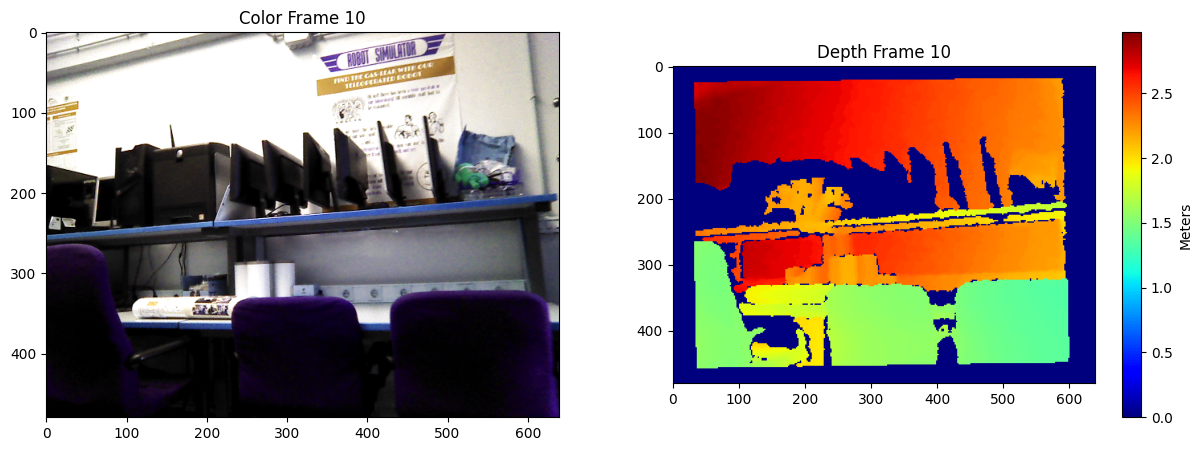

Pose (World to Camera) R:
tensor([[ 0.3139, -0.0091,  0.9494],
        [-0.9493,  0.0114,  0.3140],
        [-0.0137, -0.9999, -0.0050]])
Pose (World to Camera) T:
tensor([-0.8431,  1.0368, -4.0636])


In [3]:
# Visualizar un frame aleatorio
idx = 10
cam_info = reader.get_camera(idx)

img = cam_info.image.permute(1, 2, 0).cpu().numpy()
depth = cam_info.depth.cpu().numpy() if cam_info.depth is not None else None

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title(f"Color Frame {idx}")
plt.imshow(img / 255.0)
plt.subplot(1, 2, 2)
plt.title(f"Depth Frame {idx}")
if depth is not None:
    plt.imshow(depth, cmap='jet')
    plt.colorbar(label='Meters')
plt.show()

print(f"Pose (World to Camera) R:\n{cam_info.R}")
print(f"Pose (World to Camera) T:\n{cam_info.T}")

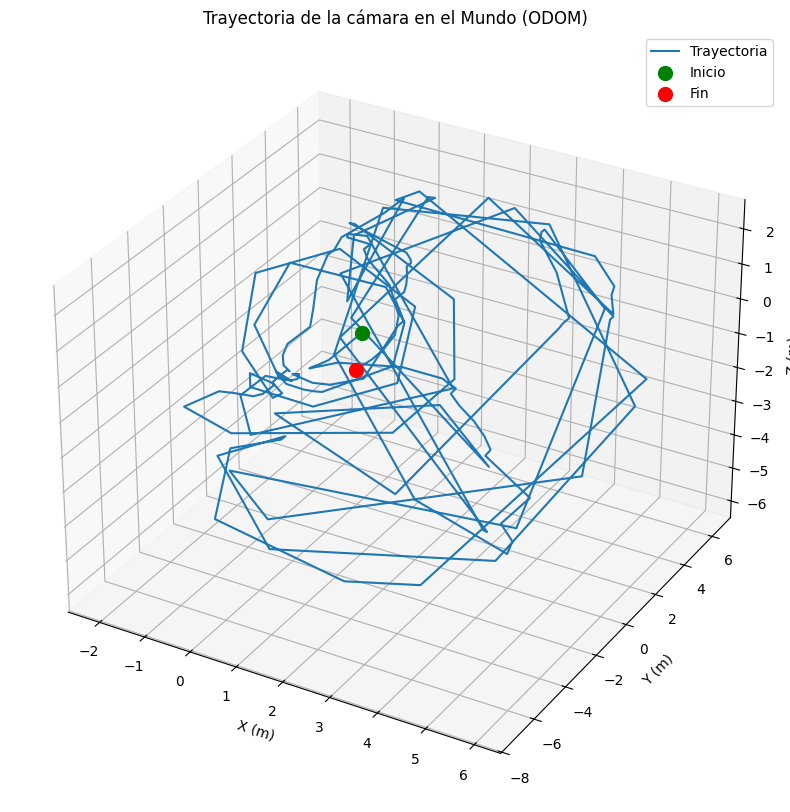

In [4]:
# Proyección de puntos 3D básica para ver si la trayectoria tiene sentido
all_pos = []
for i in range(len(reader.frames)):
    c = reader.get_camera(i)
    # T_c2w = -R_w2c^T * T_w2c
    pos = -c.R.T @ c.T
    all_pos.append(pos.cpu().numpy())

all_pos = np.array(all_pos)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot(all_pos[:, 0], all_pos[:, 1], all_pos[:, 2], label='Trayectoria')
ax.scatter(all_pos[0, 0], all_pos[0, 1], all_pos[0, 2], color='green', s=100, label='Inicio')
ax.scatter(all_pos[-1, 0], all_pos[-1, 1], all_pos[-1, 2], color='red', s=100, label='Fin')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.legend()
plt.title("Trayectoria de la cámara en el Mundo (ODOM)")
plt.show()